In [5]:
# !pip install lightgbm shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score, recall_score, f1_score, balanced_accuracy_score,
    roc_auc_score, average_precision_score, confusion_matrix, brier_score_loss
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.calibration import CalibratedClassifierCV



pd.set_option("display.max_columns", 200)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)



In [8]:
DATA_PATH = "monthly_master (1).csv"   # ajustá si está en otra carpeta
df0 = pd.read_csv(DATA_PATH)
print(df0.shape)
df0.head()



(87111, 44)


,store_id,period_month,tpn,gmv,days_with_orders,markdown_mean,avg_shipping_cost,si_ios_prop,si_meli_prop,si_other_prop,free_shipping_prop,w_tpn_w1,w_tpn_w2,w_tpn_w3,w_tpn_w4,w_tpn_w5,w_gmv_w1,w_gmv_w2,w_gmv_w3,w_gmv_w4,w_gmv_w5,w_tpn_w6,w_gmv_w6,churn,churn_streak,churn_2m_consec,churn_4m_consec_or_more,churn_unique,stage,created_date,segmento,comision_actual,in-house_delivery,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,ciudad,total_min_open,total_min_paused,total_min_closed,total_minutes_all
0,100000,2024-10,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-10-24,Top Players,19.5,0,Brand expansion,martinez oeste,Pollo,10.0,0.0,13736,GBA,NaN,NaN,NaN,NaN
1,100000,2024-11,10.0,99900.0,4,0.192647,1122.625000,0.250000,0.000000,0.0,0.500000,2.0,NaN,NaN,NaN,NaN,22600.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,New,2024-10-24,Top Players,19.5,0,Brand expansion,martinez oeste,Pollo,10.0,0.0,13736,GBA,NaN,NaN,NaN,NaN
2,100000,2024-12,100.0,1494618.0,23,0.213178,1175.461111,0.444444,0.000000,0.0,0.777778,8.0,16.0,24.0,32.0,20.0,77300.0,213094.0,330634.0,519896.0,314194.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,Retained,2024-10-24,Top Players,19.5,0,Brand expansion,martinez oeste,Pollo,10.0,0.0,13736,GBA,NaN,NaN,NaN,NaN
3,100000,2025-01,78.0,1165196.0,20,0.395979,1168.689600,0.240000,0.120000,0.0,0.920000,24.0,34.0,10.0,6.0,NaN,356500.0,527500.0,137398.0,72398.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,Retained,2024-10-24,Top Players,19.5,0,Brand expansion,martinez oeste,Pollo,10.0,0.0,13736,GBA,NaN,NaN,NaN,NaN
4,100000,2025-02,48.0,808800.0,15,0.400081,1171.896667,0.166667,0.111111,0.0,1.000000,20.0,22.0,6.0,4.0,NaN,346800.0,360800.0,99400.0,65600.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,Retained,2024-10-24,Top Players,19.5,0,Brand expansion,martinez oeste,Pollo,10.0,0.0,13736,GBA,NaN,NaN,NaN,NaN


In [9]:
df = df0.copy()

# Fechas
df['period_month'] = pd.to_datetime(df['period_month'], errors='coerce')
df['created_date'] = pd.to_datetime(df.get('created_date'), errors='coerce')

# Primer día de mes de alta
df['created_month'] = df['created_date'].dt.to_period('M').dt.to_timestamp()

# Fallback si falta created_date: primer mes observado del store
first_obs = df.groupby('store_id')['period_month'].transform('min')
df['created_month'] = df['created_month'].fillna(first_obs)

# (Opcional) limitar a CABA y recortar mes incompleto si lo necesitás
ONLY_CABA = True
if ONLY_CABA and 'ciudad' in df.columns:
    df = df[df['ciudad'] == 'CABA'].copy()

CUT_BEFORE = pd.Timestamp('2025-09-01')   # evita mes incompleto septiembre 2025
df = df[df['period_month'] < CUT_BEFORE].copy()

# Población elegible (tiendas ya creadas en cada mes)
mask_alive = (df['period_month'] >= df['created_month'])
df_ctx_all = df.loc[mask_alive].sort_values(['store_id', 'period_month']).reset_index(drop=True)

print("Elegible:", df_ctx_all.shape)


Elegible: (51401, 45)


In [10]:
# Confirmar existencia del target base
if 'churn_unique' not in df_ctx_all.columns:
    raise ValueError("Falta 'churn_unique' en la base. Agregalo antes de continuar.")

# Renombrar target base si querés mantener consistencia
df_ctx_all = df_ctx_all.rename(columns={'churn_unique': 'new_churn'})

# Construir target de predicción t+1
df_ctx_all['new_churn_t+1'] = (
    df_ctx_all
    .groupby('store_id')['new_churn']
    .shift(-1)
)

# Conservar filas con target definido para entrenar/validar
df_ctx_train = df_ctx_all[df_ctx_all['new_churn_t+1'].notna()].copy()
df_ctx_train['new_churn_t+1'] = df_ctx_train['new_churn_t+1'].astype(int)

df_ctx_train[['store_id', 'period_month', 'new_churn', 'new_churn_t+1']].head()



,store_id,period_month,new_churn,new_churn_t+1
4,100006,2024-11-01,NaN,0
5,100006,2024-12-01,0.0,0
6,100006,2025-01-01,0.0,0
7,100006,2025-02-01,0.0,0
8,100006,2025-03-01,0.0,0


In [11]:
# Categóricas principales (ajustá a tu esquema)
for c in ['segmento', 'barrio', 'category']:
    if c in df_ctx_all.columns:
        df_ctx_all[c] = df_ctx_all[c].astype('category')

# Drops (evitar leakage y simplificar)
cols_drop = ['stage', 'store_type', 'si_ios_prop', 'si_meli_prop', 'si_other_prop']
df_ctx_all = df_ctx_all.drop(columns=[c for c in cols_drop if c in df_ctx_all.columns], errors='ignore')



In [12]:
num_cols = [
    'tpn','gmv','days_with_orders','markdown_mean','avg_shipping_cost',
    'free_shipping_prop','connectivity','total_min_open','total_minutes_all','churn_streak'
]

def add_lag_feats(g: pd.DataFrame, cols, lags=(1,2)):
    for c in cols:
        if c in g.columns:
            for L in lags:
                g[f'{c}_t-{L}'] = g[c].shift(L)
    return g

def add_mom_and_rolling(g: pd.DataFrame, cols):
    for c in cols:
        if c not in g.columns: 
            continue
        # MoM %
        if f'{c}_t-1' in g.columns:
            with np.errstate(divide='ignore', invalid='ignore'):
                g[f'{c}_mom_pct'] = (g[c] - g[f'{c}_t-1']) / g[f'{c}_t-1']
                g.loc[g[f'{c}_t-1'] == 0, f'{c}_mom_pct'] = np.nan
                g.loc[np.isinf(g[f'{c}_mom_pct']), f'{c}_mom_pct'] = np.nan

        # Rolling 3m (incluye t) + std + desvío vs rolling
        roll_mean = g.groupby('store_id')[c].transform(lambda x: x.rolling(3, min_periods=1).mean())
        roll_std  = g.groupby('store_id')[c].transform(lambda x: x.rolling(3, min_periods=1).std())
        g[f'{c}_rolling_avg_3m'] = roll_mean
        g[f'{c}_rolling_std_3m'] = roll_std
        g[f'{c}_dev_from_rolling_avg_3m'] = g[c] - roll_mean
    return g

def add_operational_and_history(g: pd.DataFrame):
    # open_rate_lag1 (si hay minutos)
    if 'total_min_open_t-1' in g.columns and 'total_minutes_all_t-1' in g.columns:
        den = g['total_minutes_all_t-1']
        num = g['total_min_open_t-1']
        g['open_rate_t-1'] = np.where(den > 0, num/den, np.nan)
    # historial churn
    if 'new_churn' in g.columns:
        g['churn_prev'] = g['new_churn'].shift(1)
    if 'churn_streak' in g.columns:
        g['en_churn_streak_prev'] = (g['churn_streak'].shift(1) > 0).astype(float)
    return g

df_feats = (
    df_ctx_all
      .sort_values(['store_id','period_month'])
      .groupby('store_id', group_keys=False)
      .apply(lambda g: add_lag_feats(g, num_cols))
      .groupby('store_id', group_keys=False)
      .apply(lambda g: add_mom_and_rolling(g, num_cols))
      .groupby('store_id', group_keys=False)
      .apply(add_operational_and_history)
      .reset_index(drop=True)
)

df_feats.shape


/tmp/ipykernel_2061/1815794060.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: add_lag_feats(g, num_cols))
/tmp/ipykernel_2061/1815794060.py:51: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: add_mom_and_rolling(g, num_cols))
/tmp/ipykernel_2061/1815794060.py:53: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future v

(51401, 98)

In [13]:
TARGET_COL = 'new_churn_t+1'

cat_cols = [c for c in ['segmento','barrio','category'] if c in df_feats.columns]

# Evitá usar valores “t” crudos de num_cols (trabajamos con lags/rollings)
df_work = df_feats.drop(columns=[c for c in num_cols if c in df_feats.columns], errors='ignore')

# Columnas derivadas
lag_feats = [c for c in df_work.columns if any(s in c for s in [
    '_t-','_mom_pct','_rolling_avg_3m','_rolling_std_3m','_dev_from_rolling_avg_3m',
    'open_rate_t-1','churn_prev','en_churn_streak_prev'
])]

base_cols = ['store_id','period_month', TARGET_COL] + cat_cols
Xy = df_work[base_cols + lag_feats].copy()

# Imputación simple + flags
for c in lag_feats:
    if c in Xy.columns and (str(Xy[c].dtype).startswith(('float','int'))):
        Xy[f'{c}_nanflag'] = Xy[c].isna().astype('int8')
        Xy[c] = Xy[c].fillna(0.0)

# Target como Int (permitiendo NaN para contexto no entrenable)
if TARGET_COL in Xy.columns:
    if Xy[TARGET_COL].notna().any():
        Xy[TARGET_COL] = Xy[TARGET_COL].astype('Int64')

Xy.shape, Xy.head(3)




/tmp/ipykernel_2061/288538949.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Xy[f'{c}_nanflag'] = Xy[c].isna().astype('int8')
/tmp/ipykernel_2061/288538949.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Xy[f'{c}_nanflag'] = Xy[c].isna().astype('int8')
/tmp/ipykernel_2061/288538949.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-frag

((51401, 120),
    store_id period_month  new_churn_t+1     segmento     barrio  category  \
 0    100006   2024-07-01           <NA>  Microstores  balvanera  Parrilla   
 1    100006   2024-08-01           <NA>  Microstores  balvanera  Parrilla   
 2    100006   2024-09-01           <NA>  Microstores  balvanera  Parrilla   
 
    tpn_t-1  tpn_t-2  gmv_t-1  gmv_t-2  days_with_orders_t-1  \
 0      0.0      0.0      0.0      0.0                   0.0   
 1      0.0      0.0      0.0      0.0                   0.0   
 2      0.0      0.0      0.0      0.0                   0.0   
 
    days_with_orders_t-2  markdown_mean_t-1  markdown_mean_t-2  \
 0                   0.0                0.0                0.0   
 1                   0.0                0.0                0.0   
 2                   0.0                0.0                0.0   
 
    avg_shipping_cost_t-1  avg_shipping_cost_t-2  free_shipping_prop_t-1  \
 0                    0.0                    0.0                     0.

In [14]:
train_start, train_end = "2025-04-01", "2025-06-30"
valid_start, valid_end = "2025-07-01", "2025-07-31"
test_start,  test_end  = "2025-08-01", "2025-08-31"

train_mask = Xy['period_month'].between(train_start, train_end) & Xy[TARGET_COL].notna()
valid_mask = Xy['period_month'].between(valid_start, valid_end) & Xy[TARGET_COL].notna()
test_mask  = Xy['period_month'].between(test_start,  test_end)  # en test real puede no haber label

def prepare_matrices(dfX, mask, y_col, cat_cols):
    drop_cols = [c for c in ['store_id','period_month', y_col] if c in dfX.columns]
    X = dfX.loc[mask].drop(columns=drop_cols)
    y = dfX.loc[mask, y_col] if y_col in dfX.columns and dfX.loc[mask, y_col].notna().any() else None

    # Asegurar dtypes categóricos
    cat_idx = []
    for c in cat_cols:
        if c in X.columns:
            X[c] = X[c].astype('category')
            cat_idx.append(X.columns.get_loc(c))
    return X, y, cat_idx

X_train, y_train, cat_idx = prepare_matrices(Xy, train_mask, TARGET_COL, cat_cols)
X_valid, y_valid, _       = prepare_matrices(Xy, valid_mask, TARGET_COL, cat_cols)
X_test,  y_test, _        = prepare_matrices(Xy, test_mask,  TARGET_COL, cat_cols)

print("Train:", X_train.shape, "Valid:", X_valid.shape, "Test:", X_test.shape)


Train: (9388, 117) Valid: (3657, 117) Test: (5293, 117)


In [17]:
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost", "shap"])




[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python -m pip install --upgrade pip


0

In [20]:
# === Bloque 8 (versión XGBoost con DMatrix y early stopping) ===
import xgboost as xgb

# One-hot que ya hicimos antes:
# X_train_ohe, X_valid_ohe, X_test_ohe
# y_train, y_valid, spw (scale_pos_weight) ya calculados

# 1) Armar DMatrix
dtrain = xgb.DMatrix(X_train_ohe, label=y_train)
dvalid = xgb.DMatrix(X_valid_ohe, label=y_valid)
dtest  = xgb.DMatrix(X_test_ohe)

# 2) Parámetros (equivalentes a los que veníamos usando)
xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",     # luego medimos ROC/PR/Brier afuera
    "eta": 0.05,                  # learning rate
    "max_depth": 6,
    "subsample": 0.9,
    "colsample_bytree": 0.8,
    "lambda": 5.0,                # L2
    "scale_pos_weight": float(spw),
    "verbosity": 1
}

# 3) Entrenar con early stopping
evals = [(dtrain, "train"), (dvalid, "valid")]
bst = xgb.train(
    params=xgb_params,
    dtrain=dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=50,   # paciencia
    verbose_eval=50
)

# 4) Predicciones usando el mejor número de árboles
best_it = bst.best_iteration
valid_prob = bst.predict(dvalid, iteration_range=(0, best_it + 1))
test_prob  = bst.predict(dtest,  iteration_range=(0, best_it + 1))
print(f"Best iteration: {best_it}")





[0]	train-logloss:0.66360	valid-logloss:0.66249
[50]	train-logloss:0.29108	valid-logloss:0.27827
[100]	train-logloss:0.23718	valid-logloss:0.23919
[150]	train-logloss:0.19512	valid-logloss:0.21362
[200]	train-logloss:0.15998	valid-logloss:0.19294
[250]	train-logloss:0.13510	valid-logloss:0.18003
[300]	train-logloss:0.11474	valid-logloss:0.17001
[350]	train-logloss:0.09592	valid-logloss:0.16334
[400]	train-logloss:0.08138	valid-logloss:0.15835
[450]	train-logloss:0.07159	valid-logloss:0.15576
[500]	train-logloss:0.06151	valid-logloss:0.15364
[550]	train-logloss:0.05365	valid-logloss:0.15199
[600]	train-logloss:0.04717	valid-logloss:0.15213
[617]	train-logloss:0.04502	valid-logloss:0.15209
Best iteration: 568


In [21]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, balanced_accuracy_score,
    roc_auc_score, average_precision_score, confusion_matrix, brier_score_loss
)

def fbeta_at_threshold(y_true, y_prob, beta=2.0, thr_grid=None):
    if thr_grid is None:
        thr_grid = np.linspace(0.05, 0.95, 181)
    best = {"threshold": 0.5, "fbeta": -1, "precision": None, "recall": None}
    b2 = beta**2
    for thr in thr_grid:
        yhat = (y_prob >= thr).astype(int)
        p = precision_score(y_true, yhat, zero_division=0)
        r = recall_score(y_true, yhat, zero_division=0)
        f = 0.0 if (p==0 and r==0) else (1+b2)*(p*r)/(b2*p + r + 1e-12)
        if f > best["fbeta"]:
            best = {"threshold": float(thr), "fbeta": float(f), "precision": float(p), "recall": float(r)}
    return best

def eval_bin(y_true, y_prob, thr):
    yhat = (y_prob >= thr).astype(int)
    return {
        "threshold": thr,
        "precision": precision_score(y_true, yhat, zero_division=0),
        "recall": recall_score(y_true, yhat, zero_division=0),
        "f1": f1_score(y_true, yhat, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, yhat),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true))>1 else np.nan,
        "pr_auc": average_precision_score(y_true, y_prob) if len(np.unique(y_true))>1 else np.nan,
        "brier": brier_score_loss(y_true, y_prob),
        "cm": confusion_matrix(y_true, yhat)
    }

best_f2 = fbeta_at_threshold(y_valid, valid_prob, beta=2.0)
thr = best_f2["threshold"]
print("Best F2 on VALID:", best_f2)

valid_eval = eval_bin(y_valid, valid_prob, thr)
print("\nVALID:", {k:v for k,v in valid_eval.items() if k!='cm'})
print(valid_eval['cm'])

# Si tenés y_test (etiquetas disponibles en test)
if 'new_churn_t+1' in Xy.columns and Xy.loc[test_mask, 'new_churn_t+1'].notna().any():
    y_test = Xy.loc[test_mask, 'new_churn_t+1'].astype(int).to_numpy()
    test_eval = eval_bin(y_test, test_prob, thr)
    print("\nTEST:", {k:v for k,v in test_eval.items() if k!='cm'})
    print(test_eval['cm'])
else:
    test_eval = None


Best F2 on VALID: {'threshold': 0.06, 'fbeta': 0.5614783226720403, 'precision': 0.23269513991163476, 'recall': 0.8681318681318682}

VALID: {'threshold': 0.06, 'precision': 0.23269513991163476, 'recall': 0.8681318681318682, 'f1': 0.3670150987224158, 'balanced_accuracy': 0.8591019052889557, 'roc_auc': 0.9213487232192268, 'pr_auc': 0.3429804725198061, 'brier': 0.046179873864439565}
[[2954  521]
 [  24  158]]


In [23]:
# === BLOQUE 10A: Importancia de variables (gain) ===
import pandas as pd

# Como pasamos feature_names en los DMatrix, las claves ya son nombres reales
score_gain = bst.get_score(importance_type='gain')  # dict: {feature_name: gain}
imp = (
    pd.DataFrame(list(score_gain.items()), columns=['feature', 'gain'])
    .sort_values('gain', ascending=False)
    .reset_index(drop=True)
)
imp.head(20)




,feature,gain
0,avg_shipping_cost_dev_from_rolling_avg_3m_nanflag,611.762756
1,markdown_mean_dev_from_rolling_avg_3m_nanflag,358.844421
2,free_shipping_prop_dev_from_rolling_avg_3m_nan...,294.381683
3,days_with_orders_rolling_avg_3m,65.752037
4,churn_streak_rolling_std_3m_nanflag,41.111530
5,days_with_orders_mom_pct,38.273224
6,tpn_rolling_avg_3m,35.457253
7,segmento_Top Players,34.502426
8,markdown_mean_rolling_std_3m_nanflag,26.042160
9,barrio_villa real,21.033022


/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_2061/2238115700.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train_ohe.iloc[sample_idx], show=False)


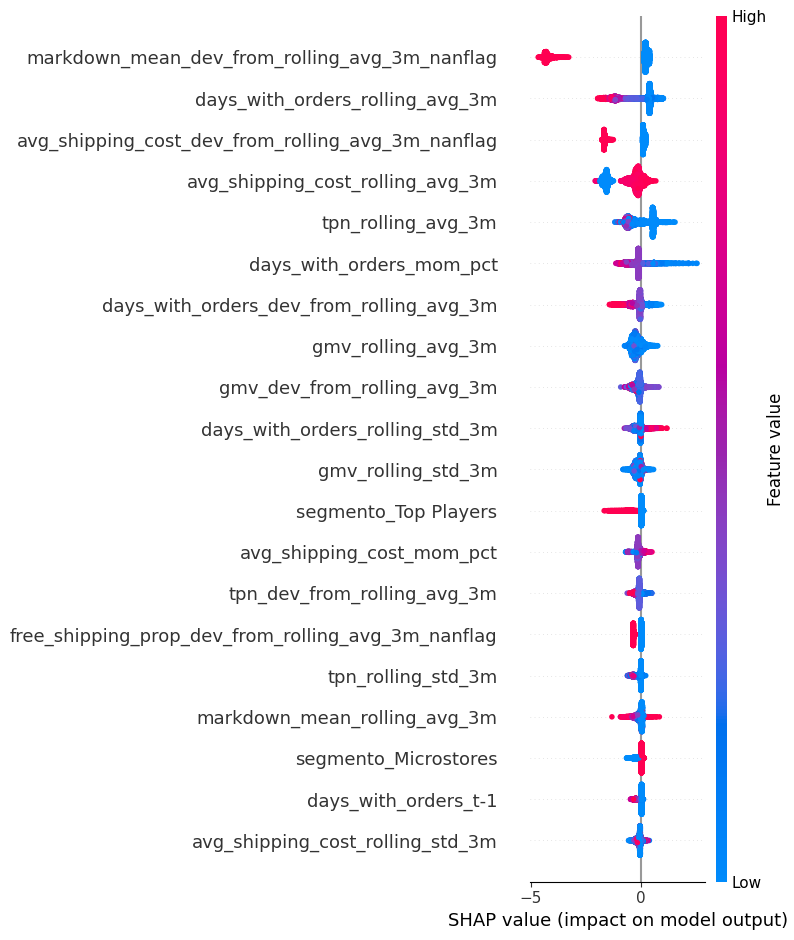

In [24]:
# === BLOQUE 10B: SHAP summary ===
import shap, matplotlib.pyplot as plt
# Submuestreo opcional por performance
sample_idx = np.random.choice(np.arange(X_train_ohe.shape[0]), size=min(5000, X_train_ohe.shape[0]), replace=False)

explainer = shap.TreeExplainer(bst)
shap_values = explainer.shap_values(X_train_ohe.iloc[sample_idx])

shap.summary_plot(shap_values, X_train_ohe.iloc[sample_idx], show=False)
plt.tight_layout(); plt.show()




In [25]:
# === BLOQUE 11: Export predicciones de TEST ===
pred_test = Xy.loc[test_mask, ['store_id','period_month']].copy()
pred_test['score'] = test_prob
pred_test['yhat']  = (pred_test['score'] >= thr).astype(int)
pred_test.head()

pred_test.to_csv("predicciones_test_xgb.csv", index=False)
print("Guardado: predicciones_test_xgb.csv")


Guardado: predicciones_test_xgb.csv


In [27]:
# === BLOQUE 12 (OPCIONAL): Calibración con validación temporal estricta ===
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
import inspect
import numpy as np

# Usamos la mejor cantidad de árboles del entrenamiento con xgb.train
best_ntrees = (bst.best_iteration + 1) if bst.best_iteration is not None else 300
print("Best n_estimators for calibration:", best_ntrees)

# Reentrenamos un wrapper sklearn (mismos params que xgb_params)
xgb_sklearn = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.8,
    reg_lambda=5.0,
    scale_pos_weight=float(spw),
    n_estimators=best_ntrees,
    random_state=42,
    n_jobs=-1
)

xgb_sklearn.fit(X_train_ohe, y_train, eval_set=[(X_valid_ohe, y_valid)], verbose=False)

# Compatibilidad sklearn: usar 'estimator' si existe, sino 'base_estimator'
sig = inspect.signature(CalibratedClassifierCV.__init__)
cal_kwargs = {"method": "sigmoid", "cv": "prefit"}
if "estimator" in sig.parameters:
    cal = CalibratedClassifierCV(estimator=xgb_sklearn, **cal_kwargs)
else:
    cal = CalibratedClassifierCV(base_estimator=xgb_sklearn, **cal_kwargs)

cal.fit(X_valid_ohe, y_valid)

valid_prob_cal = cal.predict_proba(X_valid_ohe)[:, 1]
test_prob_cal  = cal.predict_proba(X_test_ohe)[:, 1]

# Reutilizamos tus funciones de F2 y evaluación del Bloque 9
best_f2_cal = fbeta_at_threshold(y_valid, valid_prob_cal, beta=2.0)
thr_cal = best_f2_cal["threshold"]
print("Best F2 (calibrado en VALID):", best_f2_cal)

valid_eval_cal = eval_bin(y_valid, valid_prob_cal, thr_cal)
print("\nVALID (cal):", {k:v for k,v in valid_eval_cal.items() if k!='cm'})
print(valid_eval_cal['cm'])

if 'new_churn_t+1' in Xy.columns and Xy.loc[test_mask, 'new_churn_t+1'].notna().any():
    y_test = Xy.loc[test_mask, 'new_churn_t+1'].astype(int).to_numpy()
    test_eval_cal = eval_bin(y_test, test_prob_cal, thr_cal)
    print("\nTEST (cal):", {k:v for k,v in test_eval_cal.items() if k!='cm'})
    print(test_eval_cal['cm'])



Best n_estimators for calibration: 569


/home/codespace/.local/lib/python3.12/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Best F2 (calibrado en VALID): {'threshold': 0.055, 'fbeta': 0.5565371024732113, 'precision': 0.3118811881188119, 'recall': 0.6923076923076923}

VALID (cal): {'threshold': 0.055, 'precision': 0.3118811881188119, 'recall': 0.6923076923076923, 'f1': 0.4300341296928328, 'balanced_accuracy': 0.8061538461538462, 'roc_auc': 0.9227828286821093, 'pr_auc': 0.35100449989643157, 'brier': 0.039354344835443006}
[[3197  278]
 [  56  126]]


In [28]:
# === BLOQUE 13 (OPCIONAL): CV temporal de sanity-check ===
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=3)
scores = []
Xy_trainable = Xy[Xy['new_churn_t+1'].notna()].copy().sort_values('period_month')

def split_idx_by_tscv(df):
    idx = np.arange(df.shape[0])
    for tr, va in tscv.split(idx):
        yield tr, va

for fold, (tr_idx, va_idx) in enumerate(split_idx_by_tscv(Xy_trainable), 1):
    tr_df = Xy_trainable.iloc[tr_idx]
    va_df = Xy_trainable.iloc[va_idx]

    X_tr, y_tr, _ = prepare_matrices(Xy_trainable, tr_df.index, 'new_churn_t+1', cat_cols)
    X_va, y_va, _ = prepare_matrices(Xy_trainable, va_df.index, 'new_churn_t+1', cat_cols)
    X_tr_ohe, X_va_ohe, _ = ohe_fit_transform(X_tr, X_va, X_va, cat_cols)

    pos = int(y_tr.sum()); neg = int((y_tr==0).sum())
    spw_fold = max(1.0, neg/max(1,pos))

    dtr = xgb.DMatrix(X_tr_ohe, label=y_tr, feature_names=X_tr_ohe.columns.tolist())
    dva = xgb.DMatrix(X_va_ohe, label=y_va, feature_names=X_tr_ohe.columns.tolist())

    params_cv = dict(xgb_params)
    params_cv["scale_pos_weight"] = float(spw_fold)

    m = xgb.train(params_cv, dtr, num_boost_round=1000, evals=[(dtr,"train"),(dva,"valid")],
                  early_stopping_rounds=50, verbose_eval=False)
    p = m.predict(dva, iteration_range=(0, m.best_iteration+1))
    best = fbeta_at_threshold(y_va, p, beta=2.0)
    ev  = eval_bin(y_va, p, best["threshold"])
    scores.append((fold, ev["roc_auc"], ev["pr_auc"], ev["f1"], ev["precision"], ev["recall"]))
    print(f"Fold {fold}: ROC {ev['roc_auc']:.3f} | PR {ev['pr_auc']:.3f} | F1 {ev['f1']:.3f} | P {ev['precision']:.3f} | R {ev['recall']:.3f}")

scores


Fold 1: ROC 0.909 | PR 0.370 | F1 0.392 | P 0.253 | R 0.866
Fold 2: ROC 0.903 | PR 0.355 | F1 0.393 | P 0.266 | R 0.751
Fold 3: ROC 0.919 | PR 0.365 | F1 0.382 | P 0.247 | R 0.844


[(1,
  0.9091224034322263,
  0.36999100784067007,
  0.3916967509025271,
  0.2530612244897959,
  0.8662674650698603),
 (2,
  0.9026587078693722,
  0.3553633396884846,
  0.39296924042686754,
  0.266156462585034,
  0.750599520383693),
 (3,
  0.9189912216685086,
  0.3647521474912153,
  0.3822525597269625,
  0.24705882352941178,
  0.8442211055276382)]